# **TikTok Project**
**Course 2 - Go Beyond the Numbers: Translate Data into Insights**

Your TikTok data team is still in the early stages of their latest project. So far, you’ve completed a project proposal and used Python to inspect and organize the TikTok dataset.

Orion Rainier, a Data Scientist at TikTok, is pleased with the work you have already completed and is requesting your assistance with some Exploratory Data Analysis (EDA) and data visualization. The management team asked to see a Python notebook showing data structuring and cleaning, as well as any matplotlib/seaborn visualizations plotted to help us understand the data. At the very least, include a graph comparing claim counts to opinion counts, as well as boxplots of the most important variables (like “video duration,” “video like count,” “video comment count,” and “video view count”) to check for outliers. Also, include a breakdown of “author ban status” counts.

Additionally, the management team has recently asked all EDA to include Tableau visualizations. Tableau visualizations are particularly helpful in status reports to the client and board members. For this data, create a Tableau dashboard showing a simple claims versus opinions count, as well as stacked bar charts of claims versus opinions for variables like video view counts, video like counts, video share counts, and video download counts. Make sure it is easy to understand to someone who isn’t data savvy, and remember that the assistant director is a person with visual impairments.

You also notice a follow-up email from the Data Science Lead, Willow Jaffey. Willow suggests including an executive summary of your analysis to share with teammates.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 2 End-of-course project: Exploratory data analysis**

In this activity, you will examine data provided and prepare it for analysis. You will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs.

Please note that the Tableau visualization activity is optional, and will not affect your completion of the course. Completing the Tableau activity will help you practice planning out and plotting a data visualization based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.
<br/>

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C1 and perform further EDA on this data with the aim of learning more about the variables. Of particular interest is information related to what distinguishes claim videos from opinion videos.

**The goal** is to explore the dataset and create visualizations.
<br/>
*This activity has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Build visualizations

**Part 4:** Evaluate and share results

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.

# **Visualize a story in Tableau and Python**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document and those below where applicable to craft your response:
1. Identify any outliers:


*   What methods are best for identifying outliers?
*   How do you make the decision to keep or exclude outliers from any future models?



Outliers can be identified using boxplots, the interquartile range (IQR) method, z-scores, and distribution plots. The decision to keep or exclude outliers depends on their context and impact. Outliers should be retained if they represent real and meaningful observations, such as highly viral videos, but removed or treated if they are due to data errors or significantly distort the analysis.

### **Task 1. Imports, links, and loading**
Go to Tableau Public
The following link will help you complete this activity. Keep Tableau Public open as you proceed to the next steps.

Link to supporting materials:
Public Tableau: https://public.tableau.com/s/. Note that the TikTok dataset can be downloaded directly from this notebook by going to "Lab Files" in the menu bar at the top of the page, clicking into the "/home/jovyan/work" folder, selecting `tiktok_dataset.csv`, and clicking "Download" above the list of files. 

For EDA of the data, import the packages that would be most helpful, such as `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn`.


In [1]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

Then, load the dataset into a dataframe. Read in the data and store it as a dataframe object.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.


In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document and those below where applicable to complete your code.

### **Task 2a: Data exploration and cleaning**

The first step is to assess your data. Check the Data Source page on Tableau Public to get a sense of the size, shape and makeup of the data set.

Consider functions that help you understand and structure the data.

*    `.head()`
*    `.info()`
*    `.describe()`
*    `.groupby()`
*    `.sort_values()`

Consider the following questions as you work:

What do you do about missing data (if any)?

Are there data outliers?

Start by discovering, using `.head()`, `.size`, and `.shape`.

In [3]:
# Display and examine the first few rows of the dataframe
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [4]:
# Get the size of the data
data.size


232584

In [6]:
# Get the shape of the data
data.shape


(19382, 12)

Get basic information about the data, using `.info()`.

In [7]:
# Get basic information about the data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate a table of descriptive statistics, using `.describe()`.

In [8]:
# Generate a table of descriptive statistics
data.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### **Task 2b. Assess data types**

In Tableau, staying on the data source page, double check the data types of the columns in the dataset. Refer to the dimensions and measures in Tableau.


Review the instructions linked in the previous Activity document to create the required Tableau visualization.

### **Task 2c. Select visualization type(s)**

Select data visualization types that will help you understand and explain the data.

Now that you know which data columns you’ll use, it is time to decide which data visualization makes the most sense for EDA of the TikTok dataset. What type of data visualization(s) would be most helpful? Consider the distribution of the data.

* Line graph
* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot
* A geographic map


The most useful visualizations for this dataset are bar charts, box plots, and histograms. Bar charts help compare categorical variables such as claim status and author ban status, box plots help identify outliers in numerical variables, and histograms help understand data distributions. Scatter plots can also be used to explore relationships between engagement metrics.

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3. Build visualizations**

Now that you have assessed your data, it’s time to plot your visualization(s).

#### **video_duration_sec**

Create a box plot to examine the spread of values in the `video_duration_sec` column.

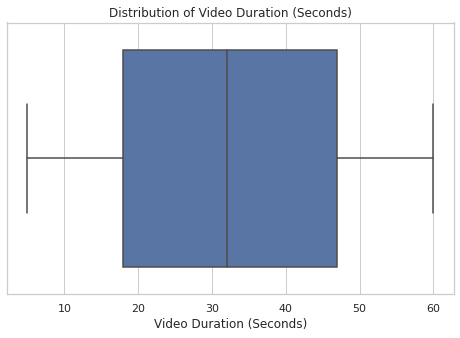

In [9]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(8,5))
sns.boxplot(x=data['video_duration_sec'])

plt.title('Distribution of Video Duration (Seconds)')
plt.xlabel('Video Duration (Seconds)')

plt.show()

Create a histogram of the values in the `video_duration_sec` column to further explore the distribution of this variable.

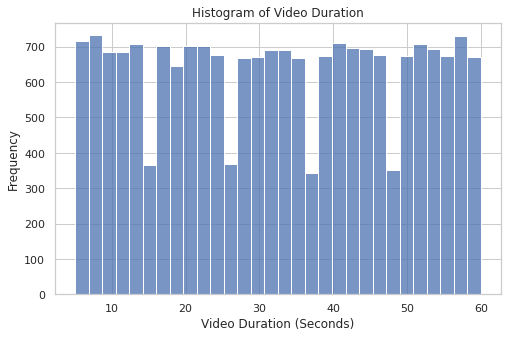

In [10]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.histplot(data['video_duration_sec'], bins=30)

plt.title('Histogram of Video Duration')
plt.xlabel('Video Duration (Seconds)')
plt.ylabel('Frequency')

plt.show()


**Question:** What do you notice about the duration and distribution of the videos?
Video durations range between approximately 5 and 60 seconds, with a median around 30 seconds. The distribution appears relatively uniform, with no significant skewness or extreme outliers, indicating that video durations are evenly spread and likely influenced by platform constraints.

#### **video_view_count**

Create a box plot to examine the spread of values in the `video_view_count` column.

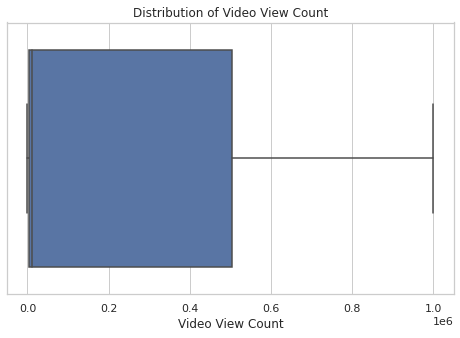

In [11]:
# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(8,5))
sns.boxplot(x=data['video_view_count'])

plt.title('Distribution of Video View Count')
plt.xlabel('Video View Count')

plt.show()

Create a histogram of the values in the `video_view_count` column to further explore the distribution of this variable.

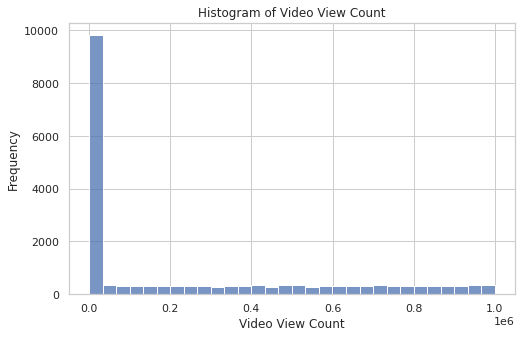

In [12]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.histplot(data['video_view_count'], bins=30)

plt.title('Histogram of Video View Count')
plt.xlabel('Video View Count')
plt.ylabel('Frequency')

plt.show()


**Question:** What do you notice about the distribution of this variable?
The distribution of video view count is highly right-skewed, with most videos having low view counts and a small number achieving extremely high views. This results in many high-end outliers, reflecting a typical pattern of viral content where a few videos dominate overall engagement.

#### **video_like_count**

Create a box plot to examine the spread of values in the `video_like_count` column.

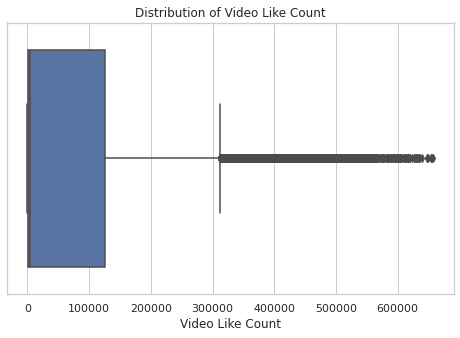

In [13]:
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(8,5))
sns.boxplot(x=data['video_like_count'])

plt.title('Distribution of Video Like Count')
plt.xlabel('Video Like Count')

plt.show()



Create a histogram of the values in the `video_like_count` column to further explore the distribution of this variable.

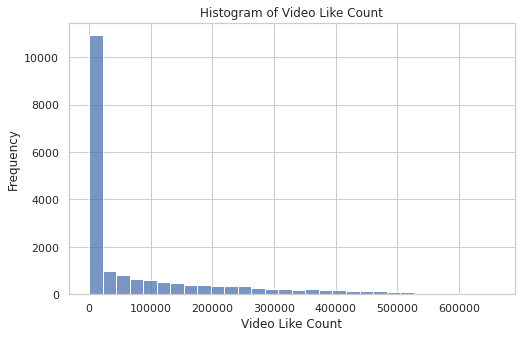

In [14]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.histplot(data['video_like_count'], bins=30)

plt.title('Histogram of Video Like Count')
plt.xlabel('Video Like Count')
plt.ylabel('Frequency')

plt.show()


**Question:** What do you notice about the distribution of this variable?
The distribution of video like count is highly right-skewed, with most videos receiving relatively low numbers of likes and a small number achieving very high engagement. This results in many high-value outliers, reflecting a typical pattern where a few viral videos account for a large share of total likes.

#### **video_comment_count**

Create a box plot to examine the spread of values in the `video_comment_count` column.

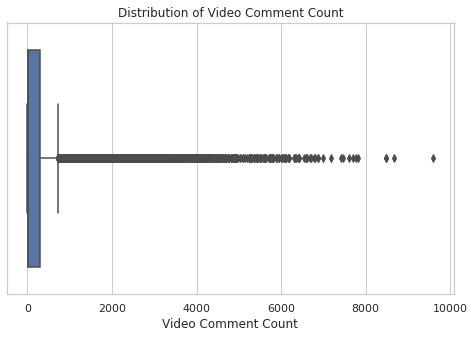

In [15]:
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(8,5))
sns.boxplot(x=data['video_comment_count'])

plt.title('Distribution of Video Comment Count')
plt.xlabel('Video Comment Count')

plt.show()



#Create a histogram of the values in the `video_comment_count` column to further explore the distribution of this variable.
plt.figure(figsize=(8,5))
sns.histplot(data['video_comment_count'], bins=30)

plt.title('Histogram of Video Comment Count')
plt.xlabel('Video Comment Count')
plt.ylabel('Frequency')

plt.show()


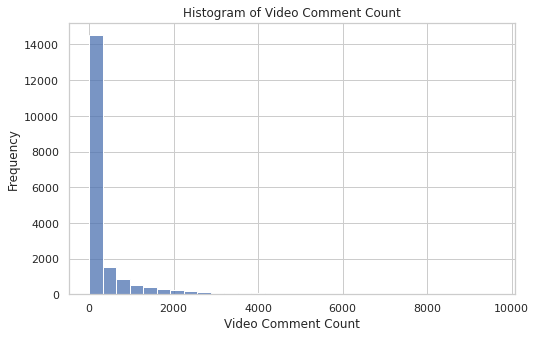

In [16]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.histplot(data['video_comment_count'], bins=30)

plt.title('Histogram of Video Comment Count')
plt.xlabel('Video Comment Count')
plt.ylabel('Frequency')

plt.show()


**Question:** What do you notice about the distribution of this variable?
The distribution of video comment count is highly right-skewed, with most videos receiving very few comments and a small number generating extremely high engagement. This results in a large number of outliers and a long right tail, indicating that only a few videos drive the majority of user interaction through comments.

#### **video_share_count**

Create a box plot to examine the spread of values in the `video_share_count` column.

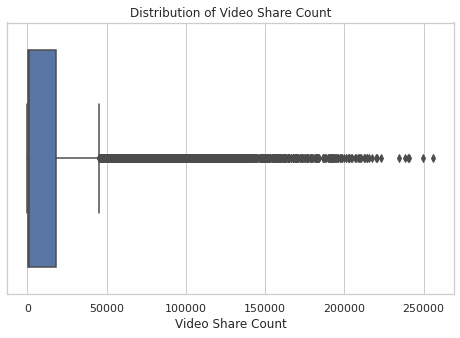

In [17]:
# Create a boxplot to visualize distribution of `video_share_count`
plt.figure(figsize=(8,5))
sns.boxplot(x=data['video_share_count'])

plt.title('Distribution of Video Share Count')
plt.xlabel('Video Share Count')

plt.show()


*Create* a histogram of the values in the `video_share_count` column to further explore the distribution of this variable.


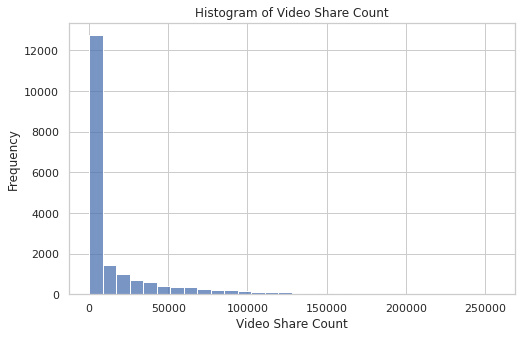

In [18]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.histplot(data['video_share_count'], bins=30)

plt.title('Histogram of Video Share Count')
plt.xlabel('Video Share Count')
plt.ylabel('Frequency')

plt.show()


**Question:** What do you notice about the distribution of this variable?
The distribution of video share count is highly right-skewed, with most videos having low share counts and a small number achieving very high shares. This results in many high-value outliers and a long tail, indicating that only a few videos drive the majority of sharing activity.

#### **video_download_count**

Create a box plot to examine the spread of values in the `video_download_count` column.

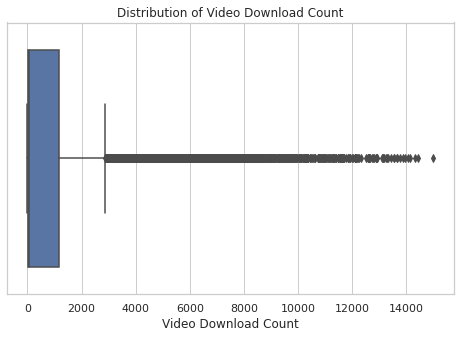

In [19]:
# Create a boxplot to visualize distribution of `video_download_count`
plt.figure(figsize=(8,5))
sns.boxplot(x=data['video_download_count'])

plt.title('Distribution of Video Download Count')
plt.xlabel('Video Download Count')

plt.show()


Create a histogram of the values in the `video_download_count` column to further explore the distribution of this variable.

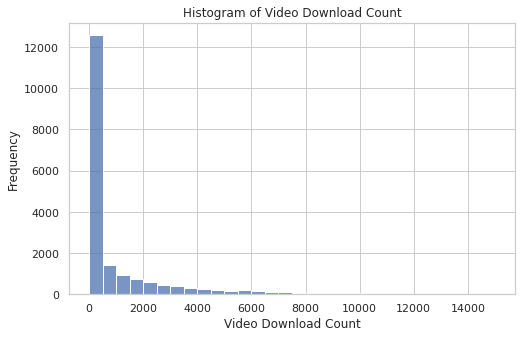

In [20]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.histplot(data['video_download_count'], bins=30)

plt.title('Histogram of Video Download Count')
plt.xlabel('Video Download Count')
plt.ylabel('Frequency')

plt.show()


**Question:** What do you notice about the distribution of this variable?
The distribution of video download count is highly right-skewed, with most videos having low download counts and a small number achieving very high downloads. This results in a long right tail and many outliers, indicating that only a few videos generate significant download activity.

#### **Claim status by verification status**

Now, create a histogram with four bars: one for each combination of claim status and verification status.

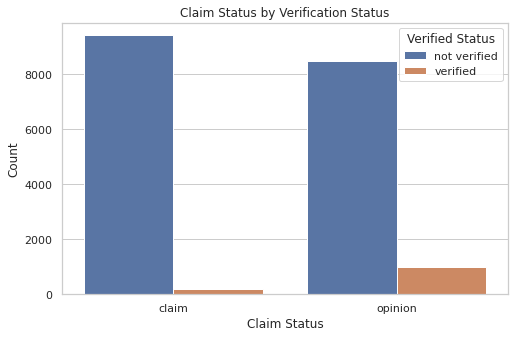

In [21]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='claim_status', hue='verified_status')

plt.title('Claim Status by Verification Status')
plt.xlabel('Claim Status')
plt.ylabel('Count')
plt.legend(title='Verified Status')

plt.show()


**Question:** What do you notice about the number of verified users compared to unverified? And how does that affect their likelihood to post opinions?
The number of unverified users is significantly higher than verified users, indicating that most content is generated by unverified accounts. Additionally, verified users are more likely to post opinions rather than claims, suggesting that verified accounts tend to share more credible or personal content, while unverified users contribute more to claim-based content.

#### **Claim status by author ban status**

The previous course used a `groupby()` statement to examine the count of each claim status for each author ban status. Now, use a histogram to communicate the same information.

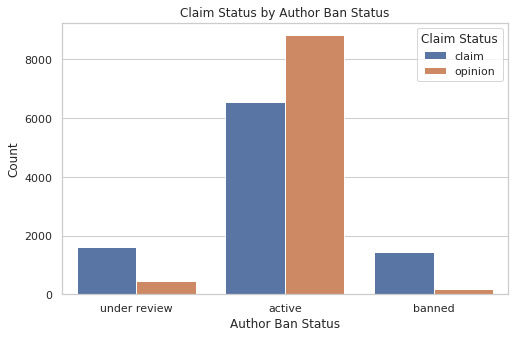

In [22]:
# Create a histogram
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='author_ban_status', hue='claim_status')

plt.title('Claim Status by Author Ban Status')
plt.xlabel('Author Ban Status')
plt.ylabel('Count')
plt.legend(title='Claim Status')

plt.show()


**Question:** What do you notice about the number of active authors compared to banned authors for both claims and opinions?
Active authors significantly outnumber banned authors for both claims and opinions, indicating that most content is generated by users in good standing. Banned authors contribute very little content, and claims appear slightly more frequent than opinions among restricted users.

#### **Median view counts by ban status**

Create a bar plot with three bars: one for each author ban status. The height of each bar should correspond with the median number of views for all videos with that author ban status.

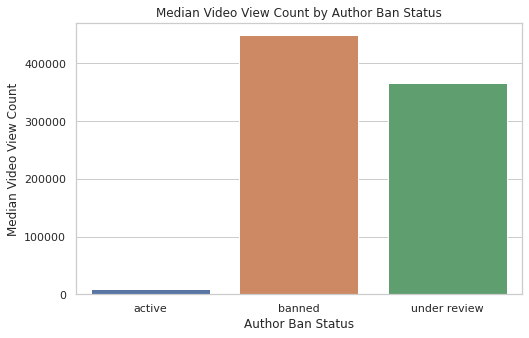

In [23]:
# Create a bar plot
median_views = data.groupby('author_ban_status')['video_view_count'].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=median_views, x='author_ban_status', y='video_view_count')

plt.title('Median Video View Count by Author Ban Status')
plt.xlabel('Author Ban Status')
plt.ylabel('Median Video View Count')

plt.show()

**Question:** What do you notice about the median view counts for non-active authors compared to that of active authors? Based on that insight, what variable might be a good indicator of claim status?

Non-active authors (banned and under review) have significantly higher median view counts compared to active authors. This suggests that highly viewed content is more likely to be associated with restricted accounts. Based on this insight, video view count may serve as a useful indicator of claim status, as higher engagement could be linked to claim-based or controversial content.

In [ ]:
# Calculate the median view count for claim status.
### YOUR CODE HERE ###

In [24]:
median_views_claim = data.groupby('claim_status')['video_view_count'].median()

median_views_claim

claim_status
claim      501555.0
opinion      4953.0
Name: video_view_count, dtype: float64

#### **Total views by claim status**

Create a pie graph that depicts the proportions of total views for claim videos and total views for opinion videos.

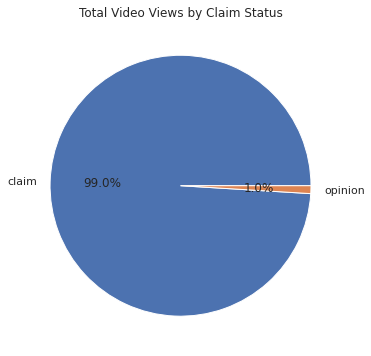

In [25]:
# Create a pie graph
total_views = data.groupby('claim_status')['video_view_count'].sum()

# Create a pie chart
plt.figure(figsize=(6,6))
plt.pie(total_views, labels=total_views.index, autopct='%1.1f%%')

plt.title('Total Video Views by Claim Status')

plt.show()


**Question:** What do you notice about the overall view count for claim status?

Claim videos account for the vast majority of total views, representing approximately 99% of overall engagement, while opinion videos contribute only a small fraction. This indicates that claim-based content generates significantly higher viewer engagement and is more likely to go viral compared to opinion-based content.

### **Task 4. Determine outliers**

When building predictive models, the presence of outliers can be problematic. For example, if you were trying to predict the view count of a particular video, videos with extremely high view counts might introduce bias to a model. Also, some outliers might indicate problems with how data was captured or recorded.

The ultimate objective of the TikTok project is to build a model that predicts whether a video is a claim or opinion. The analysis you've performed indicates that a video's engagement level is strongly correlated with its claim status. There's no reason to believe that any of the values in the TikTok data are erroneously captured, and they align with expectation of how social media works: a very small proportion of videos get super high engagement levels. That's the nature of viral content.

Nonetheless, it's good practice to get a sense of just how many of your data points could be considered outliers. The definition of an outlier can change based on the details of your project, and it helps to have domain expertise to decide a threshold. You've learned that a common way to determine outliers in a normal distribution is to calculate the interquartile range (IQR) and set a threshold that is 1.5 * IQR above the 3rd quartile.

In this TikTok dataset, the values for the count variables are not normally distributed. They are heavily skewed to the right. One way of modifying the outlier threshold is by calculating the **median** value for each variable and then adding 1.5 * IQR. This results in a threshold that is, in this case, much lower than it would be if you used the 3rd quartile.

Write a for loop that iterates over the column names of each count variable. For each iteration:
1. Calculate the IQR of the column
2. Calculate the median of the column
3. Calculate the outlier threshold (median + 1.5 * IQR)
4. Calculate the numer of videos with a count in that column that exceeds the outlier threshold
5. Print "Number of outliers, {column name}: {outlier count}"

```
Example:
Number of outliers, video_view_count: ___
Number of outliers, video_like_count: ___
Number of outliers, video_share_count: ___
Number of outliers, video_download_count: ___
Number of outliers, video_comment_count: ___
```

In [26]:
# List of count variables
count_cols = [
    'video_view_count',
    'video_like_count',
    'video_share_count',
    'video_download_count',
    'video_comment_count'
]

# Loop through each column
for col in count_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    median = data[col].median()
    
    threshold = median + 1.5 * IQR
    
    outliers = data[data[col] > threshold].shape[0]
    
    print(f"Number of outliers, {col}: {outliers}")

Number of outliers, video_view_count: 2343
Number of outliers, video_like_count: 3468
Number of outliers, video_share_count: 3732
Number of outliers, video_download_count: 3733
Number of outliers, video_comment_count: 3882


#### **Scatterplot**

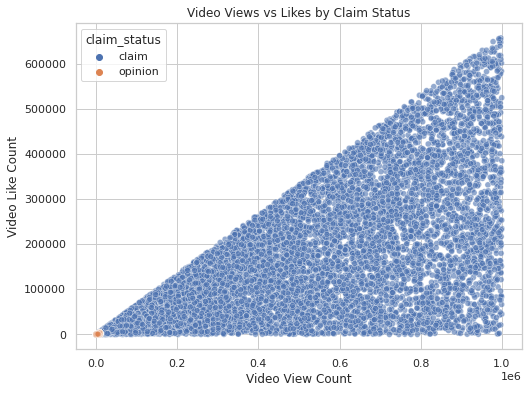

In [27]:
# Create a scatterplot of `video_view_count` versus `video_like_count` according to 'claim_status'
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x='video_view_count',
    y='video_like_count',
    hue='claim_status',
    alpha=0.6
)

plt.title('Video Views vs Likes by Claim Status')
plt.xlabel('Video View Count')
plt.ylabel('Video Like Count')

plt.show()


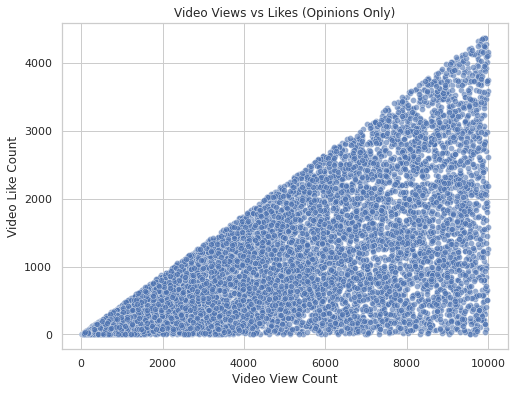

In [28]:
# Create a scatterplot of ``video_view_count` versus `video_like_count` for opinions only
# Filter for opinions only
opinions = data[data['claim_status'] == 'opinion']

# Create scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=opinions,
    x='video_view_count',
    y='video_like_count',
    alpha=0.6
)

plt.title('Video Views vs Likes (Opinions Only)')
plt.xlabel('Video View Count')
plt.ylabel('Video Like Count')

plt.show()



You can do a scatterplot in Tableau Public as well, which can be easier to manipulate and present. If you'd like step by step instructions, you can review the instructions linked in the previous Activity page.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 5a. Results and evaluation**

Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue?

***Pro tip:*** Put yourself in your client's perspective, what would they want to know?

Use the following code cells to pursue any additional EDA. Also use the space to make sure your visualizations are clean, easily understandable, and accessible.

***Ask yourself:*** Did you consider color, contrast, emphasis, and labeling?


I have learned that the dataset shows strong differences in engagement between claim and opinion videos. Claim videos dominate total views and are more likely to generate high engagement, indicating that they are more likely to go viral. Additionally, all engagement variables (views, likes, shares, comments, downloads) are highly right-skewed, meaning that a small number of videos account for the majority of engagement. I also observed that non-active authors (banned or under review) tend to have higher median view counts, suggesting a possible relationship between high engagement and problematic content. Verified users are fewer and are more likely to post opinions rather than claims.

My other questions are:

Are claim videos consistently receiving higher engagement across all metrics (likes, shares, comments)?
What characteristics (duration, verification status, ban status) best distinguish claim videos from opinion videos?
Is there a threshold of views or likes beyond which a video is more likely to be a claim?
How does engagement behavior differ between verified and unverified users?
Are highly engaged videos more likely to result in account restrictions?

My client would likely want to know which variables are the strongest predictors of claim status, especially engagement metrics such as video_view_count and video_like_count. They would also be interested in understanding how to prioritize content for moderation, particularly whether highly viewed or highly shared videos are more likely to contain claims. Additionally, the client may want recommendations on handling outliers and whether viral content should be treated differently when building predictive models.


### **Task 5b. Conclusion**
*Make it professional and presentable*

You have visualized the data you need to share with the director now. Remember, the goal of a data visualization is for an audience member to glean the information on the chart in mere seconds.

*Questions to ask yourself for reflection:*
Why is it important to conduct Exploratory Data Analysis? What other visuals could you create?


EDA is important because ...



EDA is important because it allows analysts to understand the structure, quality, and underlying patterns of the data before building predictive models. Through EDA, issues such as missing values, outliers, and skewed distributions can be identified and addressed early, ensuring more reliable and accurate analysis. In this project, EDA revealed that engagement variables are highly skewed and that claim videos generate significantly higher engagement than opinion videos. These insights are critical for guiding feature selection and model development.

EDA also helps uncover relationships between variables, such as the link between high view counts and non-active authors, which may indicate that highly viral content is more likely to be associated with claims. Without EDA, these patterns would remain hidden and could negatively impact model performance.

Additional visualizations that could be useful include:

Correlation heatmaps to examine relationships between engagement variables
Boxplots segmented by claim status to compare distributions more clearly
Log-transformed plots to better handle skewed data
Time-based visualizations (if timestamps were available) to analyze trends over time
Overall, EDA provides the foundation for informed decision-making and ensures that subsequent modeling efforts are based on a clear and accurate understanding of the data.



Visualizations helped me understand ..

Visualizations helped me understand the distribution and patterns within the dataset more clearly. Through boxplots and histograms, I was able to identify that engagement variables such as views, likes, comments, shares, and downloads are highly right-skewed, with a small number of videos generating extremely high engagement. Bar charts and count plots helped reveal differences between claim and opinion videos, showing that claim videos receive significantly higher total views and engagement. Additionally, visualizations highlighted relationships between variables, such as higher view counts among non-active authors, which may indicate a link between viral content and claim status. Overall, visualizations made complex data easier to interpret quickly and supported more informed insights and conclusions.


You’ve now completed a professional data visualization according to a business need. Well done! Be sure to save your work as a reference for later work in Tableau.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.